In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing

from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
stopwords=set(STOPWORDS)
import re

df=pd.read_csv("Automatic Ticket Assignment.csv")
df.head()

,Short description,Description,Caller,Assignment group
0,login issue,-verified user details.(employee# & manager na...,spxjnwir pjlcoqds,GRP_0
1,outlook,\r\n\r\nreceived from: hmjdrvpb.komuaywn@gmail...,hmjdrvpb komuaywn,GRP_0
2,cant log in to vpn,\r\n\r\nreceived from: eylqgodm.ybqkwiam@gmail...,eylqgodm ybqkwiam,GRP_0
3,unable to access hr_tool page,unable to access hr_tool page,xbkucsvz gcpydteq,GRP_0
4,skype error,skype error,owlgqjme qhcozdfx,GRP_0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Short description  8498 non-null   object
 1   Description        8499 non-null   object
 2   Caller             8500 non-null   object
 3   Assignment group   8500 non-null   object
dtypes: object(4)
memory usage: 265.8+ KB


In [ ]:
df.isna().sum()

,0
Short description,2
Description,1
Caller,0
Assignment group,0


In [ ]:
df["RawDescription"]=df["Short description"].str.cat(df["Description"],sep=" ",na_rep=" ")
df.head()

,Short description,Description,Caller,Assignment group,RawDescription
0,login issue,-verified user details.(employee# & manager na...,spxjnwir pjlcoqds,GRP_0,login issue -verified user details.(employee# ...
1,outlook,\r\n\r\nreceived from: hmjdrvpb.komuaywn@gmail...,hmjdrvpb komuaywn,GRP_0,outlook \r\n\r\nreceived from: hmjdrvpb.komuay...
2,cant log in to vpn,\r\n\r\nreceived from: eylqgodm.ybqkwiam@gmail...,eylqgodm ybqkwiam,GRP_0,cant log in to vpn \r\n\r\nreceived from: eylq...
3,unable to access hr_tool page,unable to access hr_tool page,xbkucsvz gcpydteq,GRP_0,unable to access hr_tool page unable to access...
4,skype error,skype error,owlgqjme qhcozdfx,GRP_0,skype error skype error


In [ ]:
df["RawWordCount"]=[len(desc.split(' ')) for desc in df["RawDescription"]]
df.head()

,Short description,Description,Caller,Assignment group,RawDescription,RawWordCount
0,login issue,-verified user details.(employee# & manager na...,spxjnwir pjlcoqds,GRP_0,login issue -verified user details.(employee# ...,31
1,outlook,\r\n\r\nreceived from: hmjdrvpb.komuaywn@gmail...,hmjdrvpb komuaywn,GRP_0,outlook \r\n\r\nreceived from: hmjdrvpb.komuay...,24
2,cant log in to vpn,\r\n\r\nreceived from: eylqgodm.ybqkwiam@gmail...,eylqgodm ybqkwiam,GRP_0,cant log in to vpn \r\n\r\nreceived from: eylq...,14
3,unable to access hr_tool page,unable to access hr_tool page,xbkucsvz gcpydteq,GRP_0,unable to access hr_tool page unable to access...,10
4,skype error,skype error,owlgqjme qhcozdfx,GRP_0,skype error skype error,6


In [ ]:
wordCount_before=df["RawWordCount"].sum()

In [ ]:
wordCount_before

np.int64(307610)

In [ ]:
font={"family":"serif","color":"darkred","weight":"normal","size":16}

In [ ]:
df=df.astype(str)

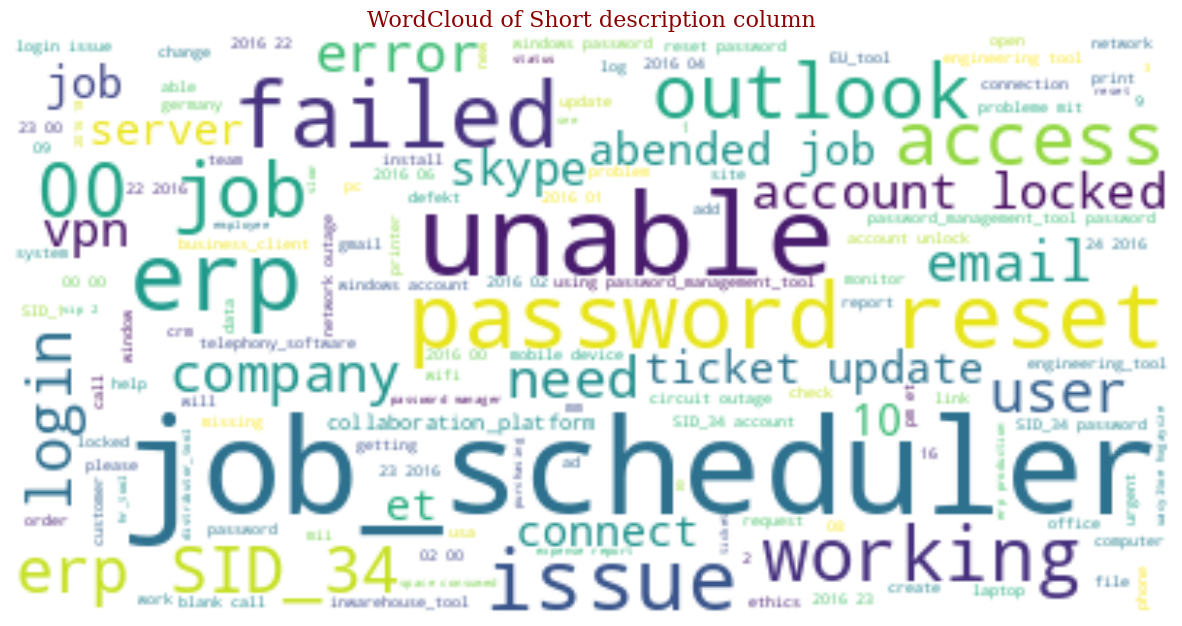

In [ ]:
All_words=""
All_words+=" ".join(df['Short description'])
wordcloud = WordCloud(background_color="white",include_numbers = True).generate(All_words)
plt.figure(figsize=(15,15))
plt.title("WordCloud of Short description column",fontdict=font)
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.show()

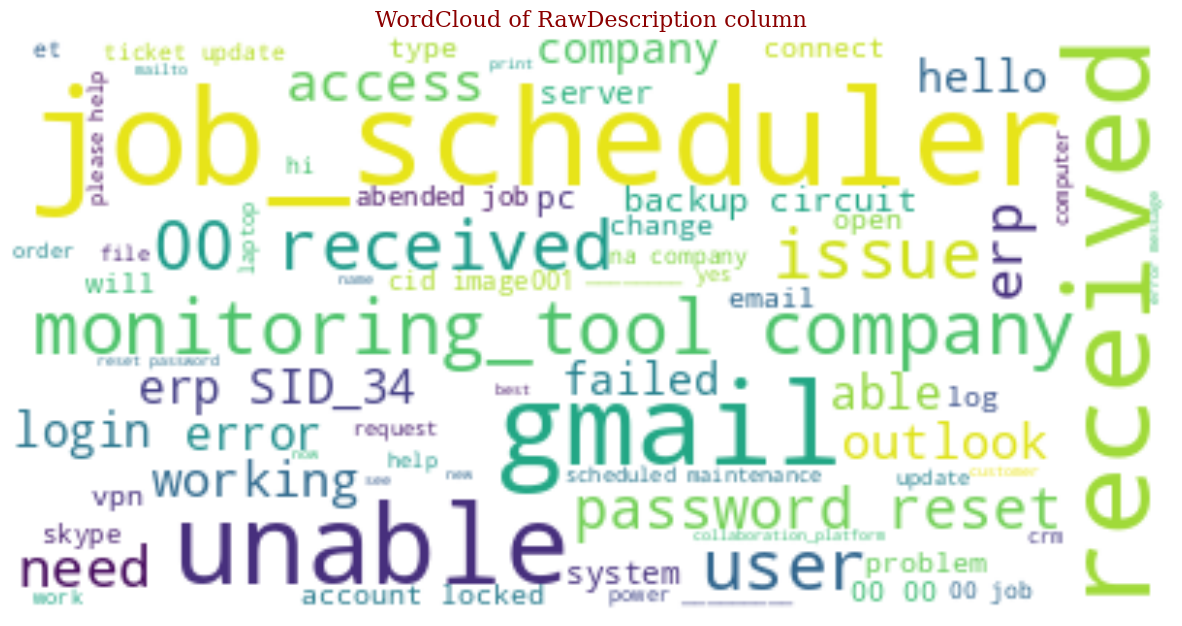

In [ ]:
All_words=""
All_words+=" ".join(df['RawDescription'])
wordcloud = WordCloud(background_color="white",include_numbers = True).generate(All_words)
plt.figure(figsize=(15,15))
plt.title("WordCloud of RawDescription column",fontdict=font)
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.show()

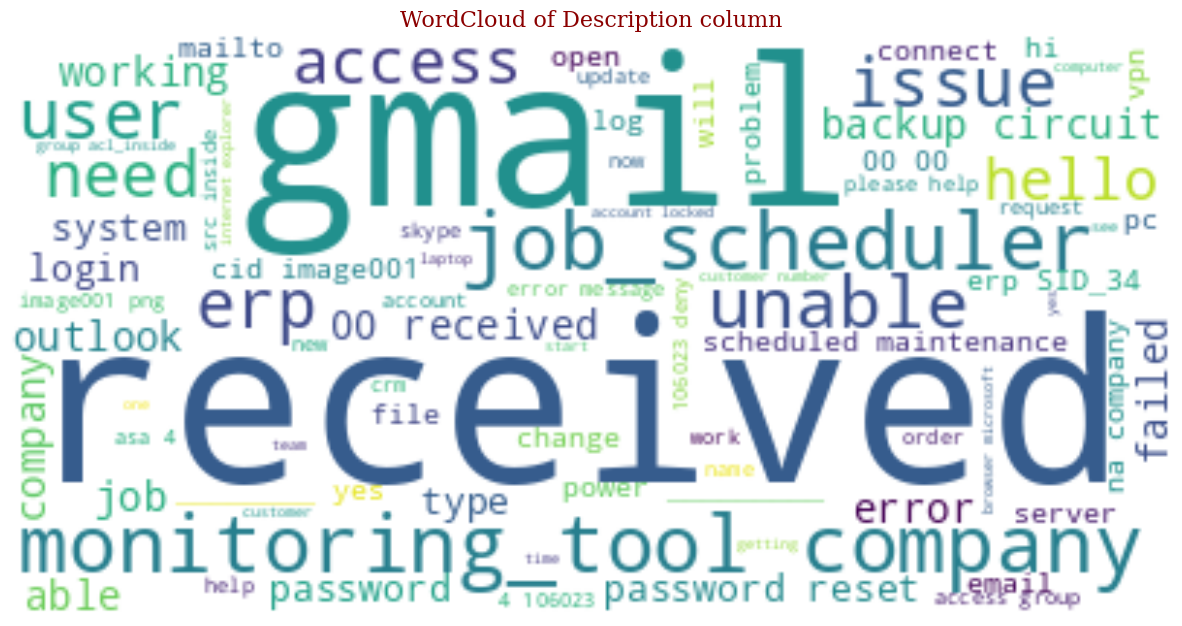

In [ ]:
All_words=""
All_words+=" ".join(df['Description'])
wordcloud = WordCloud(background_color="white",include_numbers = True).generate(All_words)
plt.figure(figsize=(15,15))
plt.title("WordCloud of Description column",fontdict=font)
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.show()

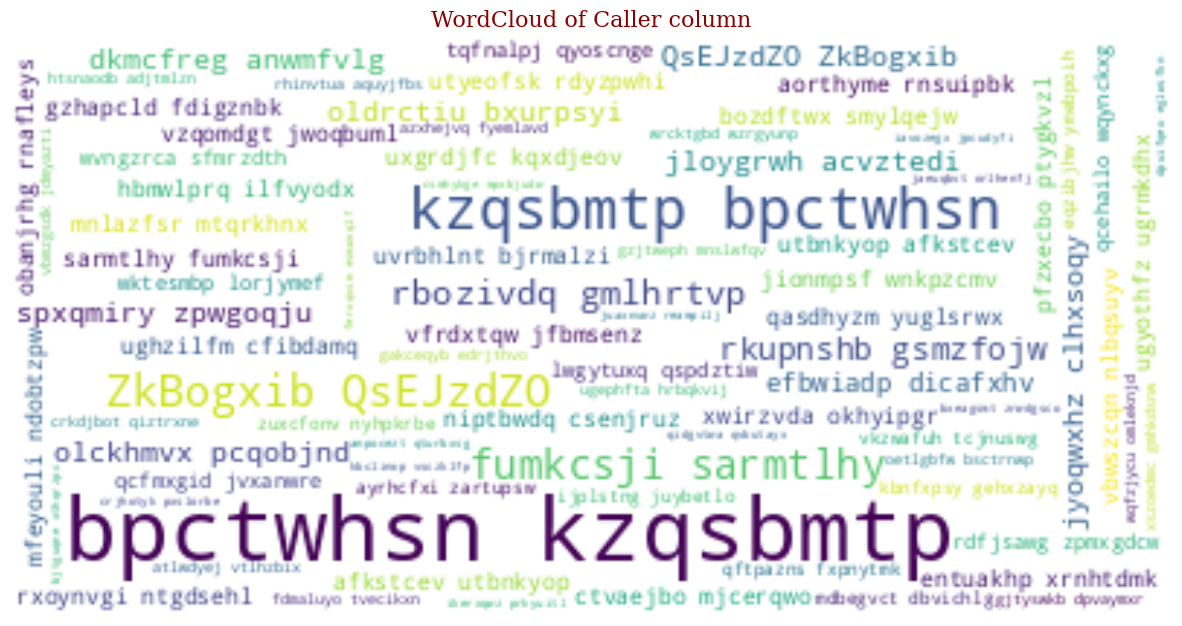

In [ ]:
All_words=""
All_words+=" ".join(df['Caller'])
wordcloud = WordCloud(background_color="white",include_numbers = True).generate(All_words)
plt.figure(figsize=(15,15))
plt.title("WordCloud of Caller column",fontdict=font)
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.show()

<Axes: title={'center': 'Class Label Discription'}, xlabel='Assignment group'>

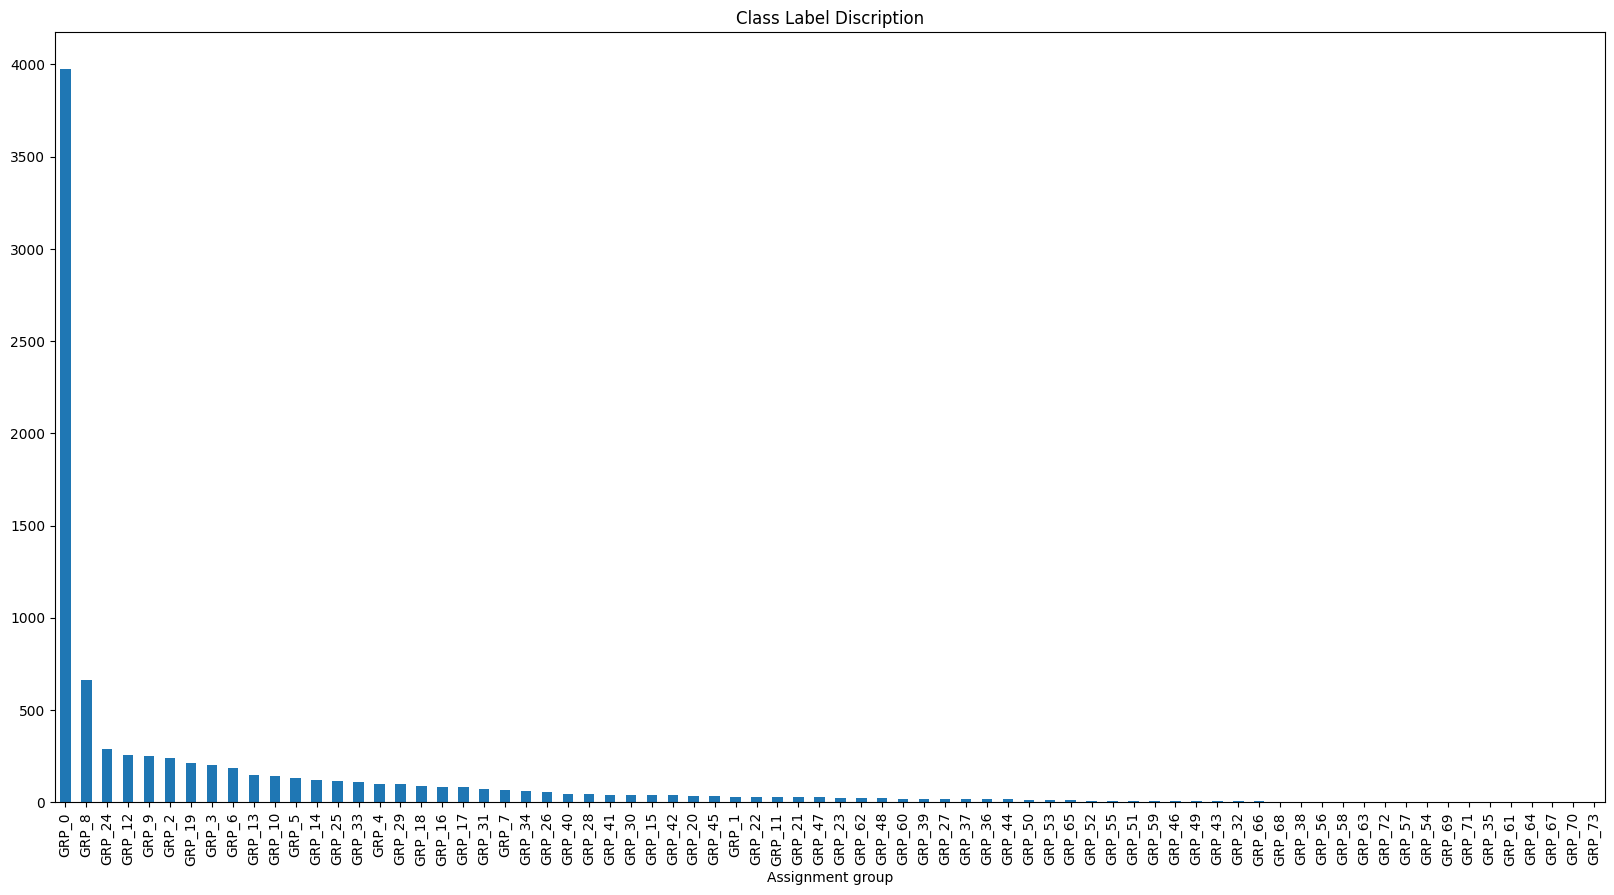

In [ ]:
df["Assignment group"].value_counts().plot(kind="bar",figsize=(20,10),title="Class Label Discription")

In [ ]:
def clean_data(text):
    text=text.lower()
    #text = ' '.join([w for w in text.split() if not is_valid_date(w)])
    text = re.sub(r"received from:",' ',text)
    text = re.sub(r"from:",' ',text)
    text = re.sub(r"to:",' ',text)
    text = re.sub(r"subject:",' ',text)
    text = re.sub(r"sent:",' ',text)
    text = re.sub(r"ic:",' ',text)
    text = re.sub(r"cc:",' ',text)
    text = re.sub(r"bcc:",' ',text)
    #Remove email
    text = re.sub(r'\S*@\S*\s?', '', text)
    # Remove numbers
    text = re.sub(r'\d+','' ,text)
    # Remove Non Dictionary character-TODO
    # Remove new line characters
    text = re.sub(r'\n',' ',text)
    # Remove hashtag while keeping hashtag text
    text = re.sub(r'#','', text)
    #&
    text = re.sub(r'&;?', 'and',text)
    # Remove HTML special entities (e.g. &amp;)
    text = re.sub(r'\&\w*;', '', text)
    # Remove hyperlinks
    text = re.sub(r'https?:\/\/.\/\w', '', text)
    # Remove characters beyond Readable formart by Unicode:
    text= ''.join(c for c in text if c <= '\uFFFF')
    text = text.strip()
    # Remove unreadable characters  (also extra spaces)
    text = ' '.join(re.sub("[^\u0030-\u0039\u0041-\u005a\u0061-\u007a]", " ", text).split())
    callers = df['Caller'].unique()
    for name in callers:
        namelist = [part for part in name.split()]
        for namepart in namelist:
            text = text.replace(namepart,'')

    text = re.sub(r"\s+[a-zA-Z]\s+", ' ', text)
    text = re.sub(' +', ' ', text)
#     text = text.strip()
    return text

In [ ]:
df["CleanDescription"] = df["RawDescription"].apply(clean_data)
df.shape

(8500, 7)

In [ ]:
import re
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stop_words=set(stopwords.words("english"))

In [ ]:
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
processed_all_documents = list()

for desc in df['CleanDescription']:
    word_tokens = word_tokenize(desc)

    filtered_sentence = []

    # removing stopwords
    for w in word_tokens:
        if w not in stop_words:
            filtered_sentence.append(w)

    # lemmetization
    lemma_word = []
    wordnet_lemmatizer = WordNetLemmatizer()
    for w in filtered_sentence:
        word1 = wordnet_lemmatizer.lemmatize(w, pos = "n")  ## noun
        word2 = wordnet_lemmatizer.lemmatize(word1, pos = "v")  ## verb
        word3 = wordnet_lemmatizer.lemmatize(word2, pos = ("a"))  ## adjective
        lemma_word.append(word3)
    words = ' '.join(lemma_word)
    processed_all_documents.append(words)

In [ ]:
df['CleanDescription']=processed_all_documents

In [ ]:
df.head()

,Short description,Description,Caller,Assignment group,RawDescription,RawWordCount,CleanDescription
0,login issue,-verified user details.(employee# & manager na...,spxjnwir pjlcoqds,GRP_0,login issue -verified user details.(employee# ...,31,login issue verify user detail employee manage...
1,outlook,\r\n\r\nreceived from: hmjdrvpb.komuaywn@gmail...,hmjdrvpb komuaywn,GRP_0,outlook \r\n\r\nreceived from: hmjdrvpb.komuay...,24,outlook hello team meet skype meet etc appear ...
2,cant log in to vpn,\r\n\r\nreceived from: eylqgodm.ybqkwiam@gmail...,eylqgodm ybqkwiam,GRP_0,cant log in to vpn \r\n\r\nreceived from: eylq...,14,cant log vpn hi log vpn best
3,unable to access hr_tool page,unable to access hr_tool page,xbkucsvz gcpydteq,GRP_0,unable to access hr_tool page unable to access...,10,unable access hr tool page unable access hr to...
4,skype error,skype error,owlgqjme qhcozdfx,GRP_0,skype error skype error,6,skype error skype error


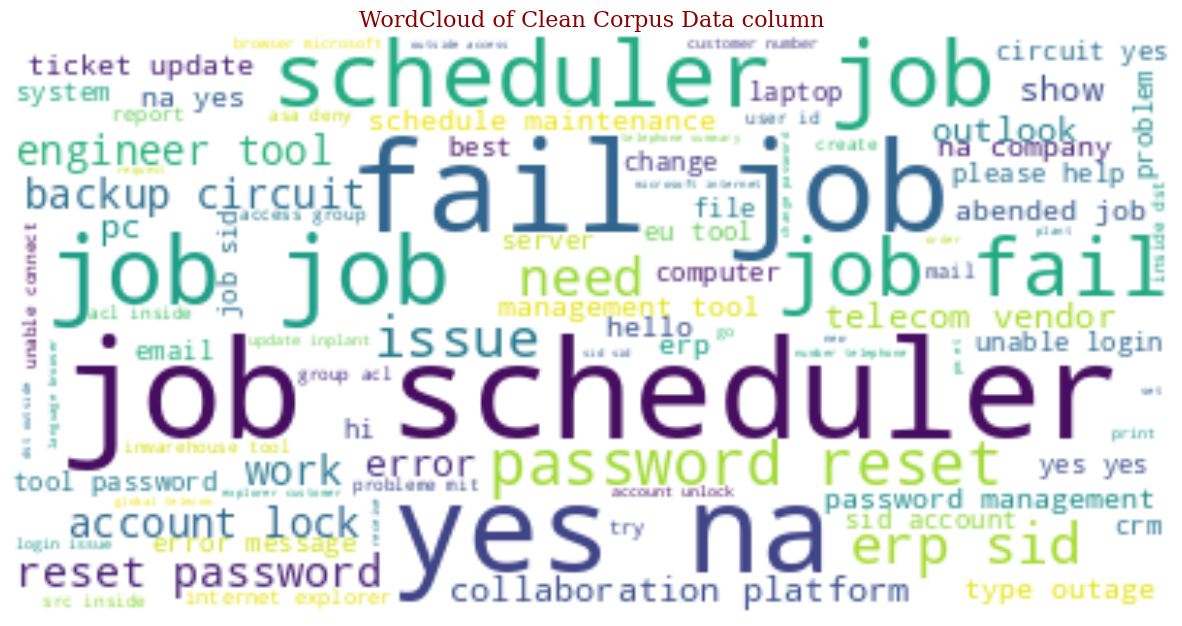

In [ ]:
All_words=""
All_words+=" ".join(df['CleanDescription'])
wordcloud = WordCloud(background_color="white",include_numbers = True).generate(All_words)
plt.figure(figsize=(15,15))
plt.title("WordCloud of Clean Corpus Data column",fontdict=font)
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
group_frequency=dict(df["Assignment group"].value_counts())
group_frequency

{'GRP_0': np.int64(3976),
 'GRP_8': np.int64(661),
 'GRP_24': np.int64(289),
 'GRP_12': np.int64(257),
 'GRP_9': np.int64(252),
 'GRP_2': np.int64(241),
 'GRP_19': np.int64(215),
 'GRP_3': np.int64(200),
 'GRP_6': np.int64(184),
 'GRP_13': np.int64(145),
 'GRP_10': np.int64(140),
 'GRP_5': np.int64(129),
 'GRP_14': np.int64(118),
 'GRP_25': np.int64(116),
 'GRP_33': np.int64(107),
 'GRP_4': np.int64(100),
 'GRP_29': np.int64(97),
 'GRP_18': np.int64(88),
 'GRP_16': np.int64(85),
 'GRP_17': np.int64(81),
 'GRP_31': np.int64(69),
 'GRP_7': np.int64(68),
 'GRP_34': np.int64(62),
 'GRP_26': np.int64(56),
 'GRP_40': np.int64(45),
 'GRP_28': np.int64(44),
 'GRP_41': np.int64(40),
 'GRP_30': np.int64(39),
 'GRP_15': np.int64(39),
 'GRP_42': np.int64(37),
 'GRP_20': np.int64(36),
 'GRP_45': np.int64(35),
 'GRP_1': np.int64(31),
 'GRP_22': np.int64(31),
 'GRP_11': np.int64(30),
 'GRP_21': np.int64(29),
 'GRP_47': np.int64(27),
 'GRP_23': np.int64(25),
 'GRP_62': np.int64(25),
 'GRP_48': np.int6

In [ ]:
group_frequency_filtered=dict(filter(lambda x: x[1] > 31, group_frequency.items()))
group_frequency_filtered

{'GRP_0': np.int64(3976),
 'GRP_8': np.int64(661),
 'GRP_24': np.int64(289),
 'GRP_12': np.int64(257),
 'GRP_9': np.int64(252),
 'GRP_2': np.int64(241),
 'GRP_19': np.int64(215),
 'GRP_3': np.int64(200),
 'GRP_6': np.int64(184),
 'GRP_13': np.int64(145),
 'GRP_10': np.int64(140),
 'GRP_5': np.int64(129),
 'GRP_14': np.int64(118),
 'GRP_25': np.int64(116),
 'GRP_33': np.int64(107),
 'GRP_4': np.int64(100),
 'GRP_29': np.int64(97),
 'GRP_18': np.int64(88),
 'GRP_16': np.int64(85),
 'GRP_17': np.int64(81),
 'GRP_31': np.int64(69),
 'GRP_7': np.int64(68),
 'GRP_34': np.int64(62),
 'GRP_26': np.int64(56),
 'GRP_40': np.int64(45),
 'GRP_28': np.int64(44),
 'GRP_41': np.int64(40),
 'GRP_30': np.int64(39),
 'GRP_15': np.int64(39),
 'GRP_42': np.int64(37),
 'GRP_20': np.int64(36),
 'GRP_45': np.int64(35)}

In [ ]:
valid_grp_list=list(group_frequency_filtered)
df=df[df["Assignment group"].isin(valid_grp_list)]
df.head(10)

,Short description,Description,Caller,Assignment group,RawDescription,RawWordCount,CleanDescription
0,login issue,-verified user details.(employee# & manager na...,spxjnwir pjlcoqds,GRP_0,login issue -verified user details.(employee# ...,31,login issue verify user detail employee manage...
1,outlook,\r\n\r\nreceived from: hmjdrvpb.komuaywn@gmail...,hmjdrvpb komuaywn,GRP_0,outlook \r\n\r\nreceived from: hmjdrvpb.komuay...,24,outlook hello team meet skype meet etc appear ...
2,cant log in to vpn,\r\n\r\nreceived from: eylqgodm.ybqkwiam@gmail...,eylqgodm ybqkwiam,GRP_0,cant log in to vpn \r\n\r\nreceived from: eylq...,14,cant log vpn hi log vpn best
3,unable to access hr_tool page,unable to access hr_tool page,xbkucsvz gcpydteq,GRP_0,unable to access hr_tool page unable to access...,10,unable access hr tool page unable access hr to...
4,skype error,skype error,owlgqjme qhcozdfx,GRP_0,skype error skype error,6,skype error skype error
5,unable to log in to engineering tool and skype,unable to log in to engineering tool and skype,eflahbxn ltdgrvkz,GRP_0,unable to log in to engineering tool and skype...,18,unable log engineer tool skype unable log engi...
7,ticket_no1550391- employment status - new non-...,ticket_no1550391- employment status - new non-...,eqzibjhw ymebpoih,GRP_0,ticket_no1550391- employment status - new non-...,18,ticket employment status new non employee ente...
8,unable to disable add ins on outlook,unable to disable add ins on outlook,mdbegvct dbvichlg,GRP_0,unable to disable add ins on outlook unable to...,14,unable disable add in outlook unable disable a...
9,ticket update on inplant_874773,ticket update on inplant_874773,fumkcsji sarmtlhy,GRP_0,ticket update on inplant_874773 ticket update ...,8,ticket update inplant ticket update inplant
10,engineering tool says not connected and unable...,engineering tool says not connected and unable...,badgknqs xwelumfz,GRP_0,engineering tool says not connected and unable...,20,engineer tool say connect unable submit report...


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=preprocessing.LabelEncoder()
df["LabelEncoding"]=le.fit_transform(df["Assignment group"])

In [ ]:
df.head()

,Short description,Description,Caller,Assignment group,RawDescription,RawWordCount,CleanDescription,LabelEncoding
0,login issue,-verified user details.(employee# & manager na...,spxjnwir pjlcoqds,GRP_0,login issue -verified user details.(employee# ...,31,login issue verify user detail employee manage...,0
1,outlook,\r\n\r\nreceived from: hmjdrvpb.komuaywn@gmail...,hmjdrvpb komuaywn,GRP_0,outlook \r\n\r\nreceived from: hmjdrvpb.komuay...,24,outlook hello team meet skype meet etc appear ...,0
2,cant log in to vpn,\r\n\r\nreceived from: eylqgodm.ybqkwiam@gmail...,eylqgodm ybqkwiam,GRP_0,cant log in to vpn \r\n\r\nreceived from: eylq...,14,cant log vpn hi log vpn best,0
3,unable to access hr_tool page,unable to access hr_tool page,xbkucsvz gcpydteq,GRP_0,unable to access hr_tool page unable to access...,10,unable access hr tool page unable access hr to...,0
4,skype error,skype error,owlgqjme qhcozdfx,GRP_0,skype error skype error,6,skype error skype error,0


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report

In [ ]:
y=np.asarray(df["LabelEncoding"])

In [ ]:
count_vect=CountVectorizer()
x_train_counts=count_vect.fit_transform(df["CleanDescription"])
print(x_train_counts.shape)

(8051, 10268)


In [ ]:
tfidf_transformer=TfidfTransformer()
x_train_tfidf=tfidf_transformer.fit_transform(x_train_counts)
x_train_tfidf.shape

(8051, 10268)

In [ ]:
train_x,test_x,train_y,test_y=train_test_split(x_train_tfidf,y,test_size=0.3)

In [ ]:
from sklearn.svm import SVC
clf=SVC(kernel="linear").fit(train_x,train_y)
y_pred = clf.predict(test_x)
print(classification_report(test_y,y_pred))

              precision    recall  f1-score   support

           0       0.68      0.98      0.80      1174
           1       0.78      0.35      0.48        40
           2       0.64      0.50      0.56        86
           3       0.76      0.45      0.57        58
           4       1.00      0.32      0.48        38
           5       0.00      0.00      0.00        14
           6       0.00      0.00      0.00        23
           7       0.80      0.67      0.73        18
           8       0.64      0.30      0.41        30
           9       0.71      0.08      0.14        64
          10       0.71      0.32      0.44        75
          11       0.00      0.00      0.00         7
          12       0.93      0.73      0.82        95
          13       0.82      0.25      0.38        36
          14       0.00      0.00      0.00        18
          15       0.00      0.00      0.00        14
          16       0.57      0.50      0.53        24
          17       0.67    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn import model_selection
from sklearn.tree import DecisionTreeClassifier
model_entropy=DecisionTreeClassifier(criterion="entropy")
model_entropy.fit(train_x,train_y)
y_pred=model_entropy.predict(test_x)
print(classification_report(y_pred,test_y))

In [ ]:
clf_pruned=DecisionTreeClassifier(criterion="entropy",random_state=100,max_depth=3,min_samples_leaf=5)
clf_pruned.fit(train_x,train_y)
preds_pruned=clf_pruned.predict(test_x)
print(classification_report(preds_pruned,test_y))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc1 = RandomForestClassifier(n_estimators=150,random_state=100,bootstrap=False)
rfc1 = rfc1.fit(train_x,train_y)
pred_RF = rfc1.predict(test_x)
acc_RF = accuracy_score(test_y,pred_RF)
f_sc = f1_score(test_y, pred_RF, average="weighted", labels=np.unique(pred_RF))